# 🌳 Hierarchical Clustering - Complete Learning Guide

## Overview
Hierarchical clustering builds a hierarchy of clusters, visualized as a dendrogram. It comes in two flavors: agglomerative (bottom-up) and divisive (top-down). Unlike K-Means, it doesn't require specifying k beforehand.

## Key Topics Covered:
1. **Agglomerative vs Divisive** - Two approaches to hierarchical clustering
2. **Linkage Methods** - Single, complete, average, Ward
3. **Dendrogram** - Tree visualization and interpretation
4. **Distance Metrics** - Euclidean and other distances
5. **Dendrogram Cutting** - Extracting clusters from dendrograms
6. **Linkage Comparison** - Understanding different linkage effects
7. **Scalability Issues** - Computational complexity
8. **Applications** - When to use hierarchical clustering

---

## References:
- [Hierarchical Clustering - Wikipedia](https://en.wikipedia.org/wiki/Hierarchical_clustering)
- [scikit-learn Hierarchical Clustering](https://scikit-learn.org/stable/modules/clustering.html#hierarchical-clustering)
- [Dendrograms Explained](https://www.youtube.com/watch?v=7xHsRkOdVwo)

## 📚 Section 1: Import Libraries

In [8]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import make_blobs, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
import warnings
warnings.filterwarnings('ignore')

# Set random seed
np.random.seed(42)

# Set matplotlib style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## 🌳 Section 2: Agglomerative Clustering Basics


🌳 EXAMPLE 1: Basic Agglomerative Clustering with Dendrogram

✅ Agglomerative Clustering Results:
  Number of clusters: 3
  Linkage method: Ward
  Cluster sizes: [7 6 7]


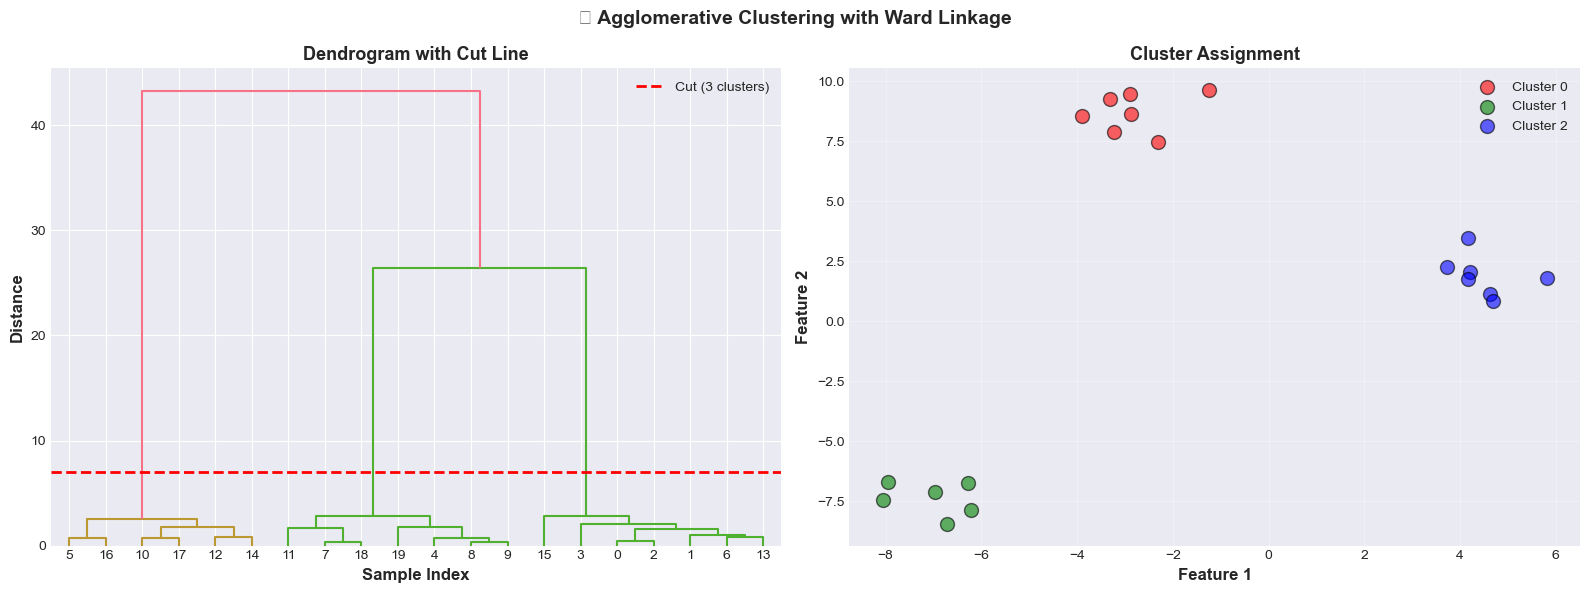

In [9]:
# Example 1: Basic Agglomerative Clustering
print("\n" + "="*70)
print("🌳 EXAMPLE 1: Basic Agglomerative Clustering with Dendrogram")
print("="*70)

# Create synthetic data
X, y_true = make_blobs(n_samples=20, centers=3, n_features=2, 
                        cluster_std=0.8, random_state=42)

# Agglomerative clustering
agg_clustering = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels = agg_clustering.fit_predict(X)

print(f"\n✅ Agglomerative Clustering Results:")
print(f"  Number of clusters: 3")
print(f"  Linkage method: Ward")
print(f"  Cluster sizes: {np.bincount(labels)}")

# Dendrogram
linkage_matrix = linkage(X, method='ward')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('🌳 Agglomerative Clustering with Ward Linkage', fontsize=14, fontweight='bold')

# Dendrogram
ax = axes[0]
dendrogram(linkage_matrix, ax=ax, leaf_font_size=10)
ax.axhline(y=7, color='r', linestyle='--', linewidth=2, label='Cut (3 clusters)')
ax.set_xlabel('Sample Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Distance', fontsize=12, fontweight='bold')
ax.set_title('Dendrogram with Cut Line', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)

# Scatter plot
ax = axes[1]
colors = ['red', 'green', 'blue']
for i in range(3):
    mask = labels == i
    ax.scatter(X[mask, 0], X[mask, 1], c=colors[i], label=f'Cluster {i}',
              s=100, alpha=0.6, edgecolors='k')

ax.set_xlabel('Feature 1', fontsize=12, fontweight='bold')
ax.set_ylabel('Feature 2', fontsize=12, fontweight='bold')
ax.set_title('Cluster Assignment', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 🔗 Section 3: Comparing Linkage Methods


🔗 EXAMPLE 2: Comparing Linkage Methods

📊 Clustering with different linkage methods:
  single    : Silhouette Score = 0.8689
  complete  : Silhouette Score = 0.8689
  average   : Silhouette Score = 0.8689
  ward      : Silhouette Score = 0.8689


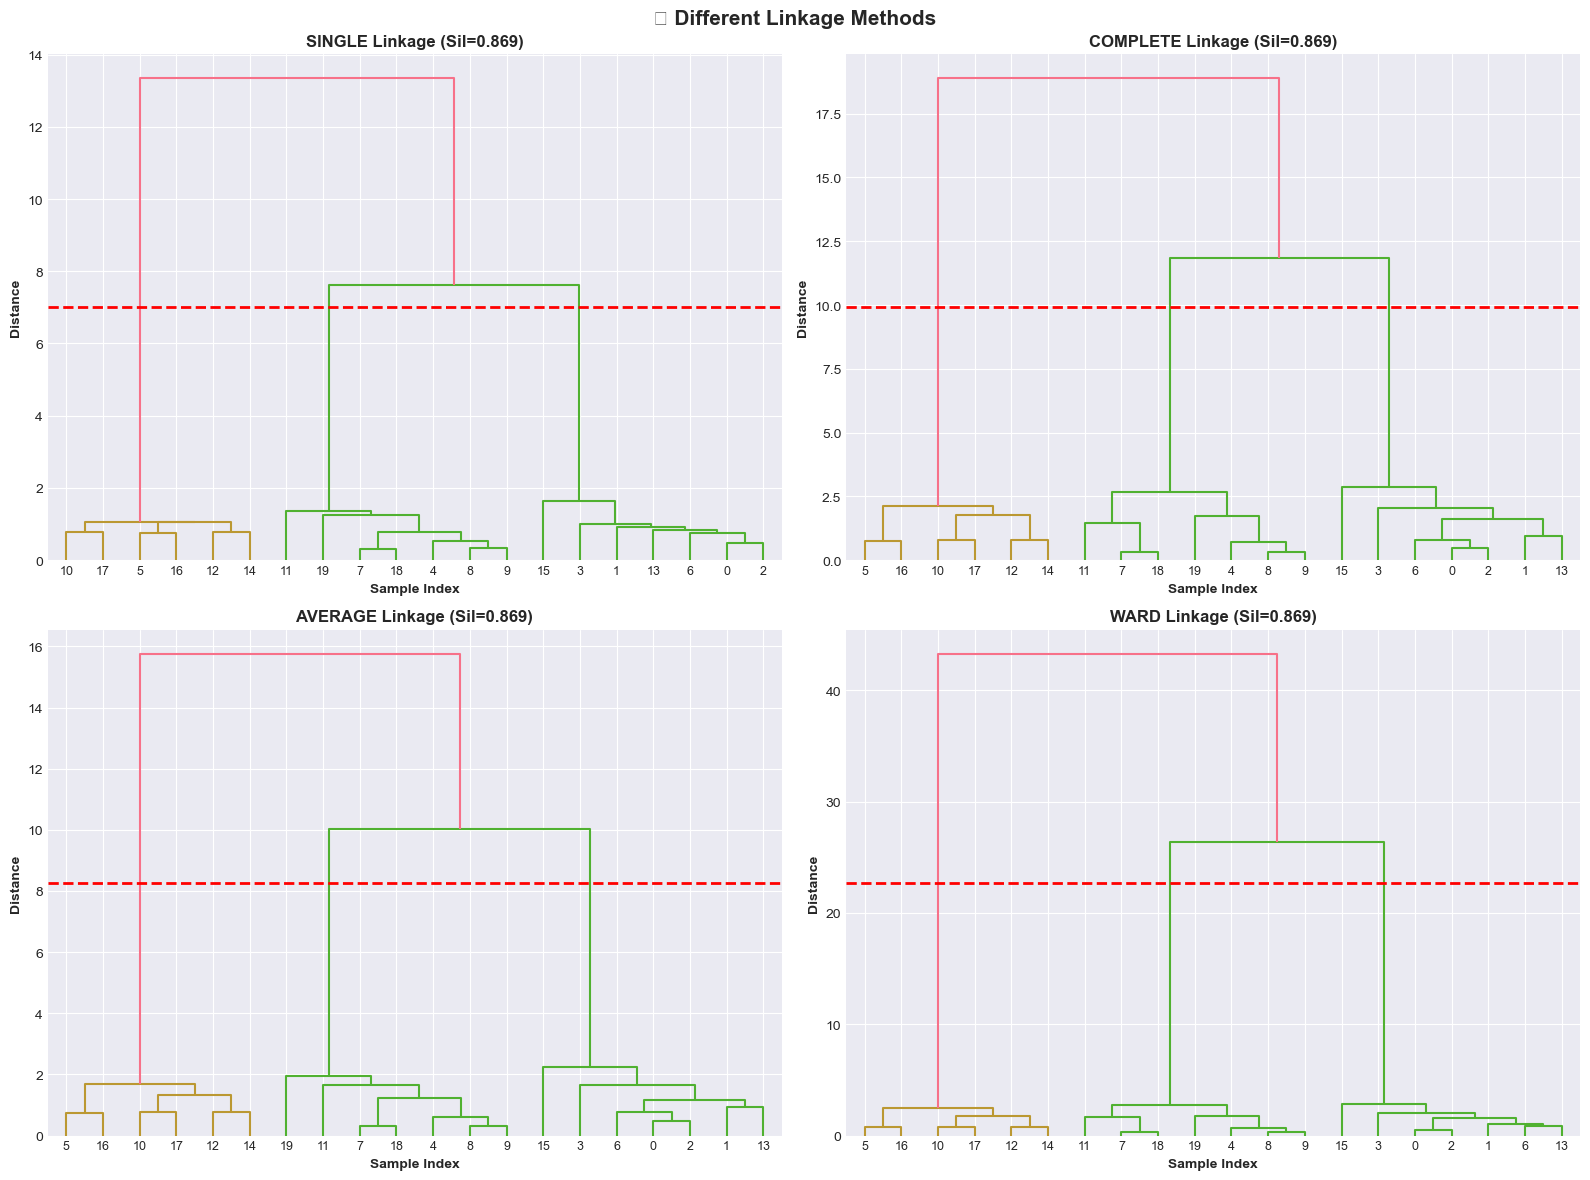


✅ Linkage Methods Summary:
  Single: Minimum distance between clusters (chains)
  Complete: Maximum distance between clusters (balanced)
  Average: Average distance between clusters (intermediate)
  Ward: Minimizes within-cluster variance (default, usually best)


In [10]:
# Example 2: Different Linkage Methods
print("\n" + "="*70)
print("🔗 EXAMPLE 2: Comparing Linkage Methods")
print("="*70)

linkage_methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🔗 Different Linkage Methods', fontsize=15, fontweight='bold')

print(f"\n📊 Clustering with different linkage methods:")
for idx, method in enumerate(linkage_methods):
    ax = axes[idx // 2, idx % 2]
    
    # Agglomerative clustering
    agg_temp = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels_temp = agg_temp.fit_predict(X)
    
    # Silhouette score
    sil_score = silhouette_score(X, labels_temp)
    print(f"  {method:10s}: Silhouette Score = {sil_score:.4f}")
    
    # Dendrogram
    linkage_matrix_temp = linkage(X, method=method)
    dendrogram(linkage_matrix_temp, ax=ax, leaf_font_size=9)
    ax.axhline(y=ax.get_ylim()[1]*0.5, color='r', linestyle='--', linewidth=2)
    ax.set_title(f'{method.upper()} Linkage (Sil={sil_score:.3f})', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sample Index', fontsize=10, fontweight='bold')
    ax.set_ylabel('Distance', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n✅ Linkage Methods Summary:")
print(f"  Single: Minimum distance between clusters (chains)")
print(f"  Complete: Maximum distance between clusters (balanced)")
print(f"  Average: Average distance between clusters (intermediate)")
print(f"  Ward: Minimizes within-cluster variance (default, usually best)")

## 📊 Section 4: Extracting Clusters from Dendrogram


📊 EXAMPLE 3: Extracting Clusters at Different Heights

🔪 Cutting dendrogram at different heights:
  2 clusters: Silhouette Score = 0.7021
  3 clusters: Silhouette Score = 0.8689
  4 clusters: Silhouette Score = 0.7034
  5 clusters: Silhouette Score = 0.5424


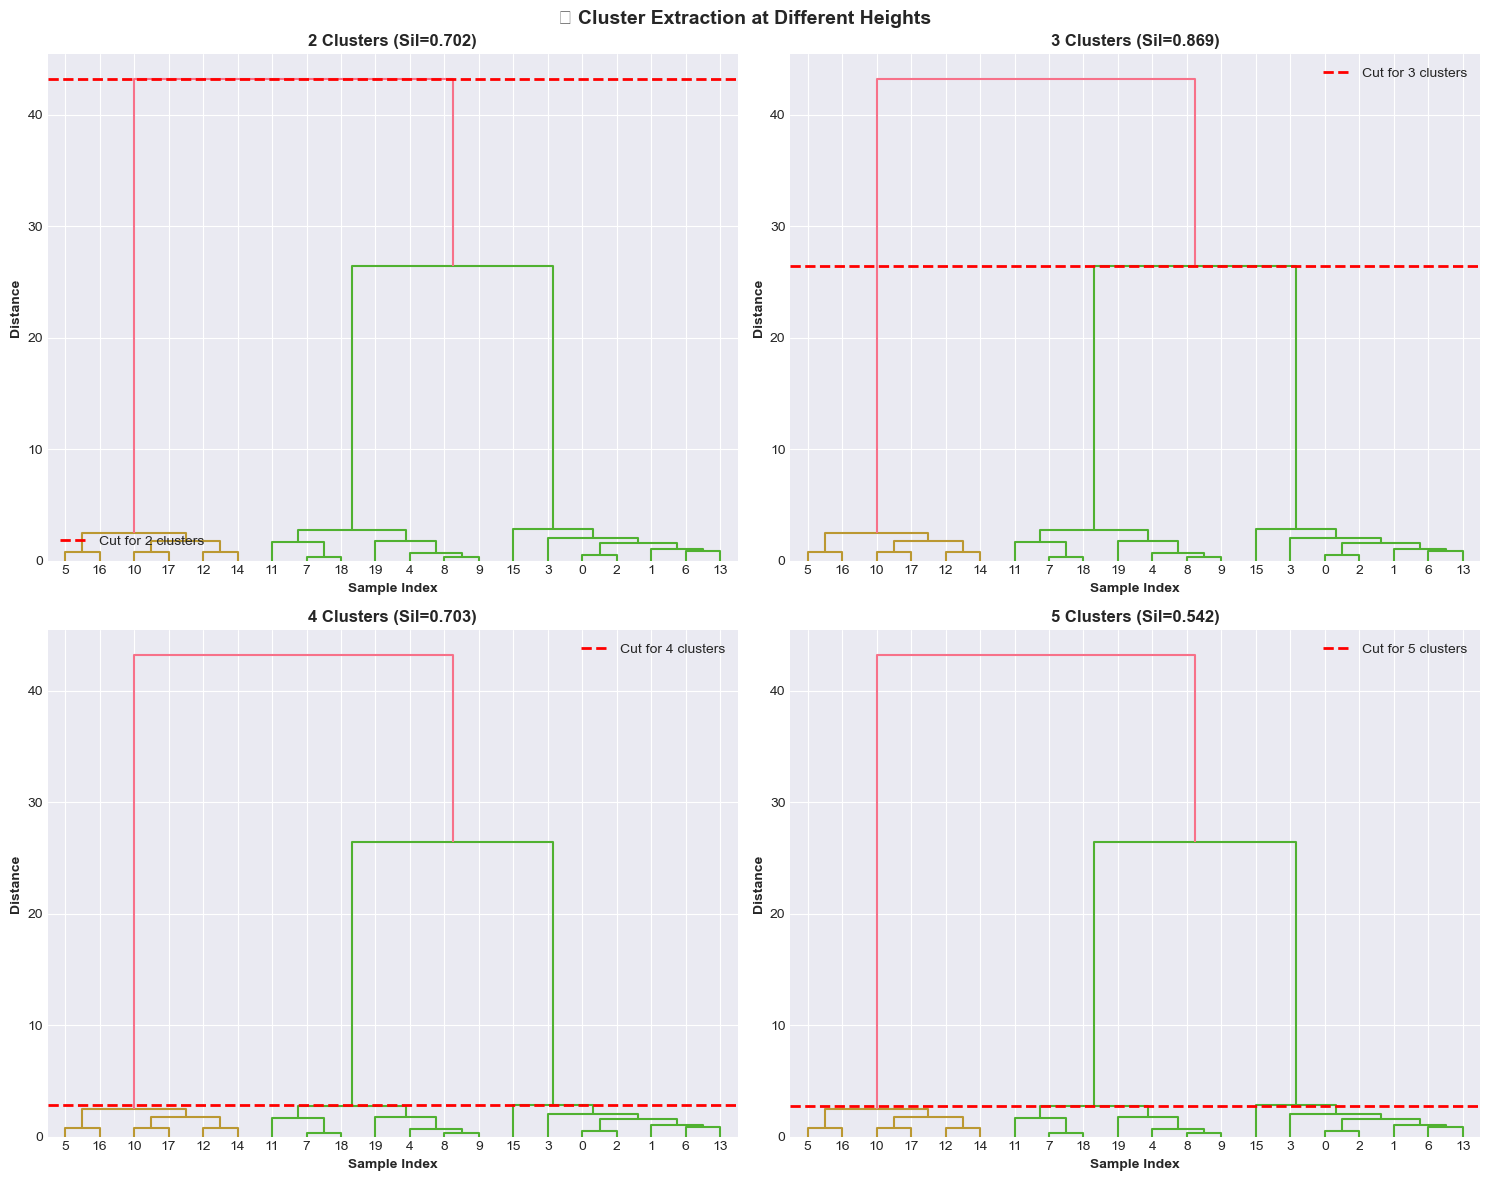

In [11]:
# Example 3: Cluster Extraction at Different Heights
print("\n" + "="*70)
print("📊 EXAMPLE 3: Extracting Clusters at Different Heights")
print("="*70)

linkage_matrix = linkage(X, method='ward')

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('📊 Cluster Extraction at Different Heights', fontsize=14, fontweight='bold')

n_clusters_list = [2, 3, 4, 5]

print(f"\n🔪 Cutting dendrogram at different heights:")
for idx, n_clust in enumerate(n_clusters_list):
    ax = axes[idx // 2, idx % 2]
    
    # Agglomerative clustering
    agg_temp = AgglomerativeClustering(n_clusters=n_clust, linkage='ward')
    labels_temp = agg_temp.fit_predict(X)
    
    sil_score = silhouette_score(X, labels_temp)
    print(f"  {n_clust} clusters: Silhouette Score = {sil_score:.4f}")
    
    # Dendrogram
    dendrogram(linkage_matrix, ax=ax, leaf_font_size=10)
    
    # Calculate cut height
    cut_height = linkage_matrix[-(n_clust-1), 2]
    ax.axhline(y=cut_height, color='r', linestyle='--', linewidth=2, label=f'Cut for {n_clust} clusters')
    
    ax.set_xlabel('Sample Index', fontsize=10, fontweight='bold')
    ax.set_ylabel('Distance', fontsize=10, fontweight='bold')
    ax.set_title(f'{n_clust} Clusters (Sil={sil_score:.3f})', fontsize=12, fontweight='bold')
    ax.legend(fontsize=10)

plt.tight_layout()
plt.show()

## 🎯 Section 5: Hierarchical Clustering on Iris


🎯 EXAMPLE 4: Hierarchical Clustering on Iris Dataset

✅ Hierarchical Clustering on Iris Dataset:
  Silhouette Score: 0.4467
  Cluster sizes: [71 49 30]


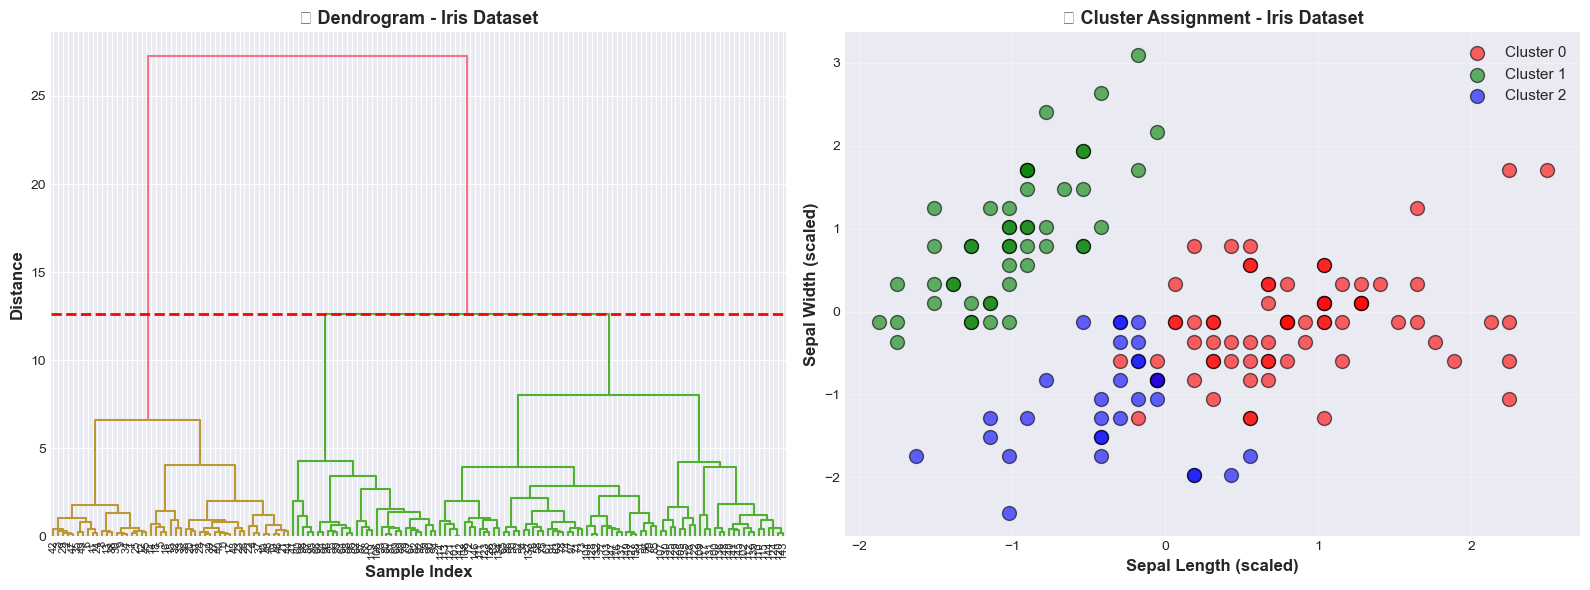

In [12]:
# Example 4: Hierarchical Clustering on Iris Dataset
print("\n" + "="*70)
print("🎯 EXAMPLE 4: Hierarchical Clustering on Iris Dataset")
print("="*70)

# Load Iris
iris = load_iris()
X_iris = iris.data

# Scale data
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)

# Apply hierarchical clustering
agg_iris = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_iris = agg_iris.fit_predict(X_iris_scaled)

# Silhouette score
sil_score_iris = silhouette_score(X_iris_scaled, labels_iris)

print(f"\n✅ Hierarchical Clustering on Iris Dataset:")
print(f"  Silhouette Score: {sil_score_iris:.4f}")
print(f"  Cluster sizes: {np.bincount(labels_iris)}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dendrogram
ax = axes[0]
linkage_iris = linkage(X_iris_scaled, method='ward')
dendrogram(linkage_iris, ax=ax, leaf_font_size=8)
ax.axhline(y=linkage_iris[-(3-1), 2], color='r', linestyle='--', linewidth=2)
ax.set_xlabel('Sample Index', fontsize=12, fontweight='bold')
ax.set_ylabel('Distance', fontsize=12, fontweight='bold')
ax.set_title('🌳 Dendrogram - Iris Dataset', fontsize=13, fontweight='bold')

# 2D scatter plot (first 2 features)
ax = axes[1]
colors = ['red', 'green', 'blue']
for i in range(3):
    mask = labels_iris == i
    ax.scatter(X_iris_scaled[mask, 0], X_iris_scaled[mask, 1], 
              c=colors[i], label=f'Cluster {i}', s=100, alpha=0.6, edgecolors='k')

ax.set_xlabel('Sepal Length (scaled)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sepal Width (scaled)', fontsize=12, fontweight='bold')
ax.set_title('🎯 Cluster Assignment - Iris Dataset', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 📈 Section 6: Distance Matrix Heatmap


📈 EXAMPLE 5: Distance Matrix Heatmap

✅ Distance Matrix Analysis:
  Number of samples: 10
  Average within-cluster distance: 1.087
  Average between-cluster distance: 11.727


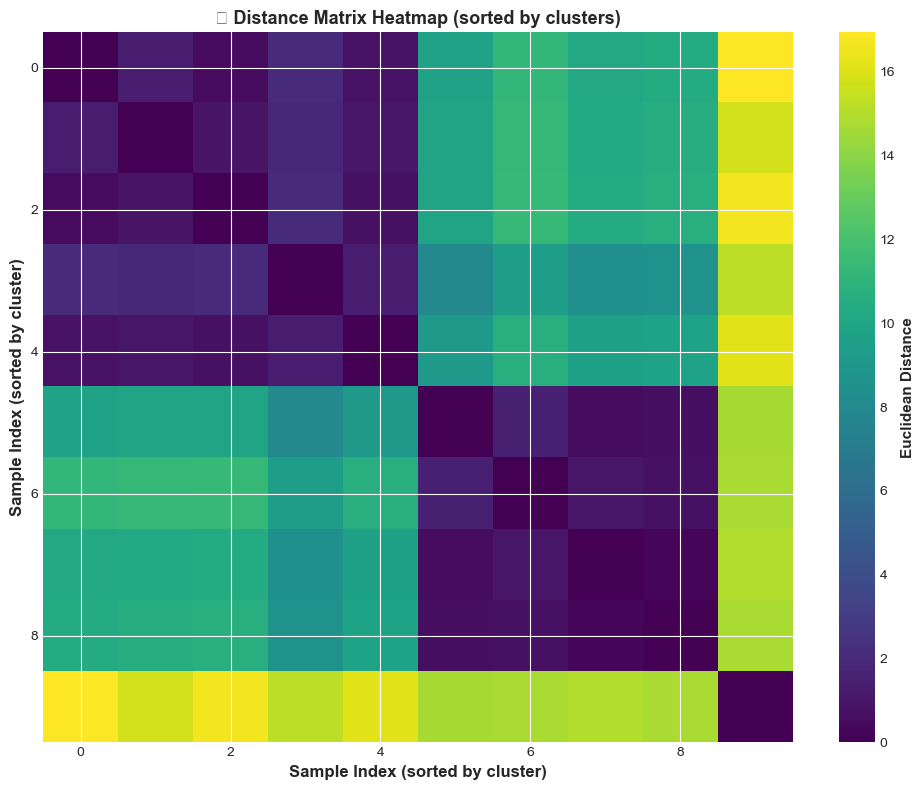

In [13]:
# Example 5: Distance Matrix Visualization
print("\n" + "="*70)
print("📈 EXAMPLE 5: Distance Matrix Heatmap")
print("="*70)

# Use small subset for clarity
X_subset = X[:10]

# Calculate pairwise distances
distances = pdist(X_subset, metric='euclidean')
dist_matrix = squareform(distances)

# Cluster labels
agg_subset = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_subset = agg_subset.fit_predict(X_subset)

print(f"\n✅ Distance Matrix Analysis:")
print(f"  Number of samples: {len(X_subset)}")
print(f"  Average within-cluster distance: {np.mean([dist_matrix[i,j] for i in range(10) for j in range(10) if labels_subset[i] == labels_subset[j] and i < j]):.3f}")
print(f"  Average between-cluster distance: {np.mean([dist_matrix[i,j] for i in range(10) for j in range(10) if labels_subset[i] != labels_subset[j]]):.3f}")

# Visualization
fig, ax = plt.subplots(figsize=(10, 8))

# Create heatmap with cluster ordering
# Sort by cluster labels for better visualization
sort_idx = np.argsort(labels_subset)
dist_matrix_sorted = dist_matrix[sort_idx][:, sort_idx]

im = ax.imshow(dist_matrix_sorted, cmap='viridis', aspect='auto')
ax.set_xlabel('Sample Index (sorted by cluster)', fontsize=12, fontweight='bold')
ax.set_ylabel('Sample Index (sorted by cluster)', fontsize=12, fontweight='bold')
ax.set_title('📈 Distance Matrix Heatmap (sorted by clusters)', fontsize=13, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Euclidean Distance', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## 📋 Section 7: Hierarchical Clustering - Advantages & Disadvantages

### ✅ Advantages:
1. **No need to specify k** - Automatic dendrogram gives flexibility
2. **Dendrogram visualization** - Easy to see clustering hierarchy
3. **Deterministic** - Same result every time (no random initialization)
4. **Works with any distance metric** - Flexible distance measures
5. **Dendrogram cutting** - Can extract different numbers of clusters
6. **Interpretable** - Tree structure is very interpretable

### ❌ Disadvantages:
1. **Computationally expensive** - O(n²) memory and O(n² log n) time
2. **Doesn't scale** - Not practical for large datasets (>10k samples)
3. **No reversal** - Can't undo previous merges (greedy algorithm)
4. **Chain effect** - Single linkage can cause chaining problem
5. **Sensitive to distance metric** - Results vary with distance choice
6. **May need preprocessing** - Feature scaling important

### When to Use:
- Small to medium datasets (<10k samples)
- When interpretability is important
- When you want to visualize clustering hierarchy
- When k is unknown
- Biological data (phylogenetic trees)
- Document clustering

In [14]:
# Example 6: Summary
print("\n" + "="*70)
print("🎓 KEY TAKEAWAYS")
print("="*70)

takeaways = [
    "Agglomerative hierarchical clustering: bottom-up approach (most common)",
    "Algorithm: Start with n clusters → Merge closest pairs → Repeat",
    "Dendrogram: Tree visualization showing merge history and distances",
    "Linkage method determines how distance between clusters is measured",
    "Ward linkage: Usually best choice (minimizes within-cluster variance)",
    "Single linkage: Can cause chaining (elongated clusters)",
    "Complete linkage: Tends to produce more compact, round clusters",
    "Average linkage: Good middle ground between single and complete",
    "No need to specify k beforehand - cut dendrogram at desired height",
    "Computational cost: O(n²) memory - limited to smaller datasets",
    "Always scale features before hierarchical clustering!",
    "For large datasets (>10k), K-Means or DBSCAN better choice"
]

for i, takeaway in enumerate(takeaways, 1):
    print(f"\n{i:2d}. {takeaway}")

print(f"\n" + "="*70)


🎓 KEY TAKEAWAYS

 1. Agglomerative hierarchical clustering: bottom-up approach (most common)

 2. Algorithm: Start with n clusters → Merge closest pairs → Repeat

 3. Dendrogram: Tree visualization showing merge history and distances

 4. Linkage method determines how distance between clusters is measured

 5. Ward linkage: Usually best choice (minimizes within-cluster variance)

 6. Single linkage: Can cause chaining (elongated clusters)

 7. Complete linkage: Tends to produce more compact, round clusters

 8. Average linkage: Good middle ground between single and complete

 9. No need to specify k beforehand - cut dendrogram at desired height

10. Computational cost: O(n²) memory - limited to smaller datasets

11. Always scale features before hierarchical clustering!

12. For large datasets (>10k), K-Means or DBSCAN better choice

